# Fire Dataset

In [2]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime
from scipy import stats

sns.set(style='whitegrid')

# Load datasets using config paths
try:
    algeria_fires = pd.read_csv(ALGERIA_FIRES_CSV)
    tunisia_fires = pd.read_csv(TUNISIA_FIRES_CSV)
    print('Loaded datasets:')
    print('Algeria:', algeria_fires.shape)
    print('Tunisia:', tunisia_fires.shape)
except Exception as e:
    print('Error loading CSVs:', e)
    algeria_fires = None
    tunisia_fires = None

# Utility: safe column presence
def has_cols(df, cols):
    if df is None:
        return False
    return all(c in df.columns for c in cols)

Loaded datasets:
Algeria: (87446, 15)
Tunisia: (2804, 15)


# 1 - Comprendre les données

Les fonctions ci-dessous inspectent la structure des DataFrames et affichent un aperçu (shape, dtypes, head/tail).

In [3]:
def show_structure(df, name='df'):
    if df is None:
        print(f'{name} is None')
        return
    print(f'=== {name} ===')
    print('\nShape:', df.shape)
    print('\nDtypes:')
    print(df.dtypes)
    print('\nHead:')
    display(df.head())
    print('\nTail:')
    display(df.tail())

# Example usage
show_structure(algeria_fires, 'Algeria fires')
show_structure(tunisia_fires, 'Tunisia fires')

=== Algeria fires ===

Shape: (87446, 15)

Dtypes:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object

Head:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2



Tail:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
87441,34.86016,-1.37439,337.17,0.43,0.46,2024-12-31,1331,N20,VIIRS,n,2,287.63,3.18,D,0
87442,35.80756,-0.34148,326.23,0.50,0.49,2024-12-31,1331,N20,VIIRS,n,2,282.76,3.58,D,2
87443,36.74493,6.25849,334.95,0.60,0.71,2024-12-31,1331,N20,VIIRS,n,2,286.65,4.28,D,2
87444,36.86816,6.98849,331.50,0.66,0.73,2024-12-31,1331,N20,VIIRS,n,2,285.38,4.55,D,2
87445,36.86970,6.98770,332.72,0.66,0.73,2024-12-31,1332,N20,VIIRS,n,2,284.90,5.24,D,2


=== Tunisia fires ===

Shape: (2804, 15)

Dtypes:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object

Head:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,31.64847,9.16945,315.79,0.53,0.50,2024-01-01,142,N20,VIIRS,n,2,279.09,2.20,N,2
1,31.49290,9.48947,302.32,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.10,1.23,N,0
2,31.49524,9.49053,301.88,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.12,0.77,N,0
3,33.36728,8.54768,302.58,0.45,0.47,2024-01-01,142,N20,VIIRS,n,2,277.15,0.80,N,2
4,31.64812,9.17107,320.80,0.46,0.39,2024-01-02,124,N20,VIIRS,n,2,278.37,2.44,N,2



Tail:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
2799,31.65023,9.17049,308.73,0.50,0.41,2024-12-30,50,N20,VIIRS,n,2,278.50,1.21,N,2
2800,31.64881,9.17031,323.63,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.46,2.57,N,2
2801,31.65072,9.16963,320.75,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.13,3.50,N,2
2802,36.59308,10.31617,296.55,0.63,0.72,2024-12-31,210,N20,VIIRS,n,2,278.94,1.12,N,2
2803,31.64872,9.17024,309.77,0.74,0.76,2024-12-31,212,N20,VIIRS,n,2,278.10,2.16,N,2


# 2 - Statistiques descriptives

Fonctions pour calculer les statistiques de base (moyenne, médiane, std, variance, mode, describe).

In [4]:
def descriptive_stats(df, numeric_only=True):
    if df is None:
        return None
    if numeric_only:
        return df.describe()
    else:
        return df.describe(include='all')

print('Descriptive stats - Algeria :\n')
print(descriptive_stats(algeria_fires))
print('\nDescriptive stats - Tunisia :\n')
print(descriptive_stats(tunisia_fires))

Descriptive stats - Algeria :

           latitude     longitude    bright_ti4          scan         track  \
count  87446.000000  87446.000000  87446.000000  87446.000000  87446.000000   
mean      31.398370      6.174013    321.170189      0.476433      0.516127   
std        2.642515      2.563073     18.189028      0.101948      0.126665   
min       19.603230     -8.118050    240.170000      0.320000      0.360000   
25%       28.735780      5.585470    305.500000      0.400000      0.400000   
50%       31.403925      6.475440    316.820000      0.450000      0.500000   
75%       32.515890      7.906365    337.420000      0.540000      0.620000   
max       37.022990     10.993650    367.000000      0.800000      0.780000   

           acq_time  version    bright_ti5           frp          type  
count  87446.000000  87446.0  87446.000000  87446.000000  87446.000000  
mean     379.367941      2.0    291.711062      3.454114      1.703863  
std      479.842612      0.0     11.71

# 3 - Analyse univariée

Histogrammes, boxplots et density plots pour chaque variable numérique.
(Exclut automatiquement les colonnes non-numériques et les colonnes inutiles.)

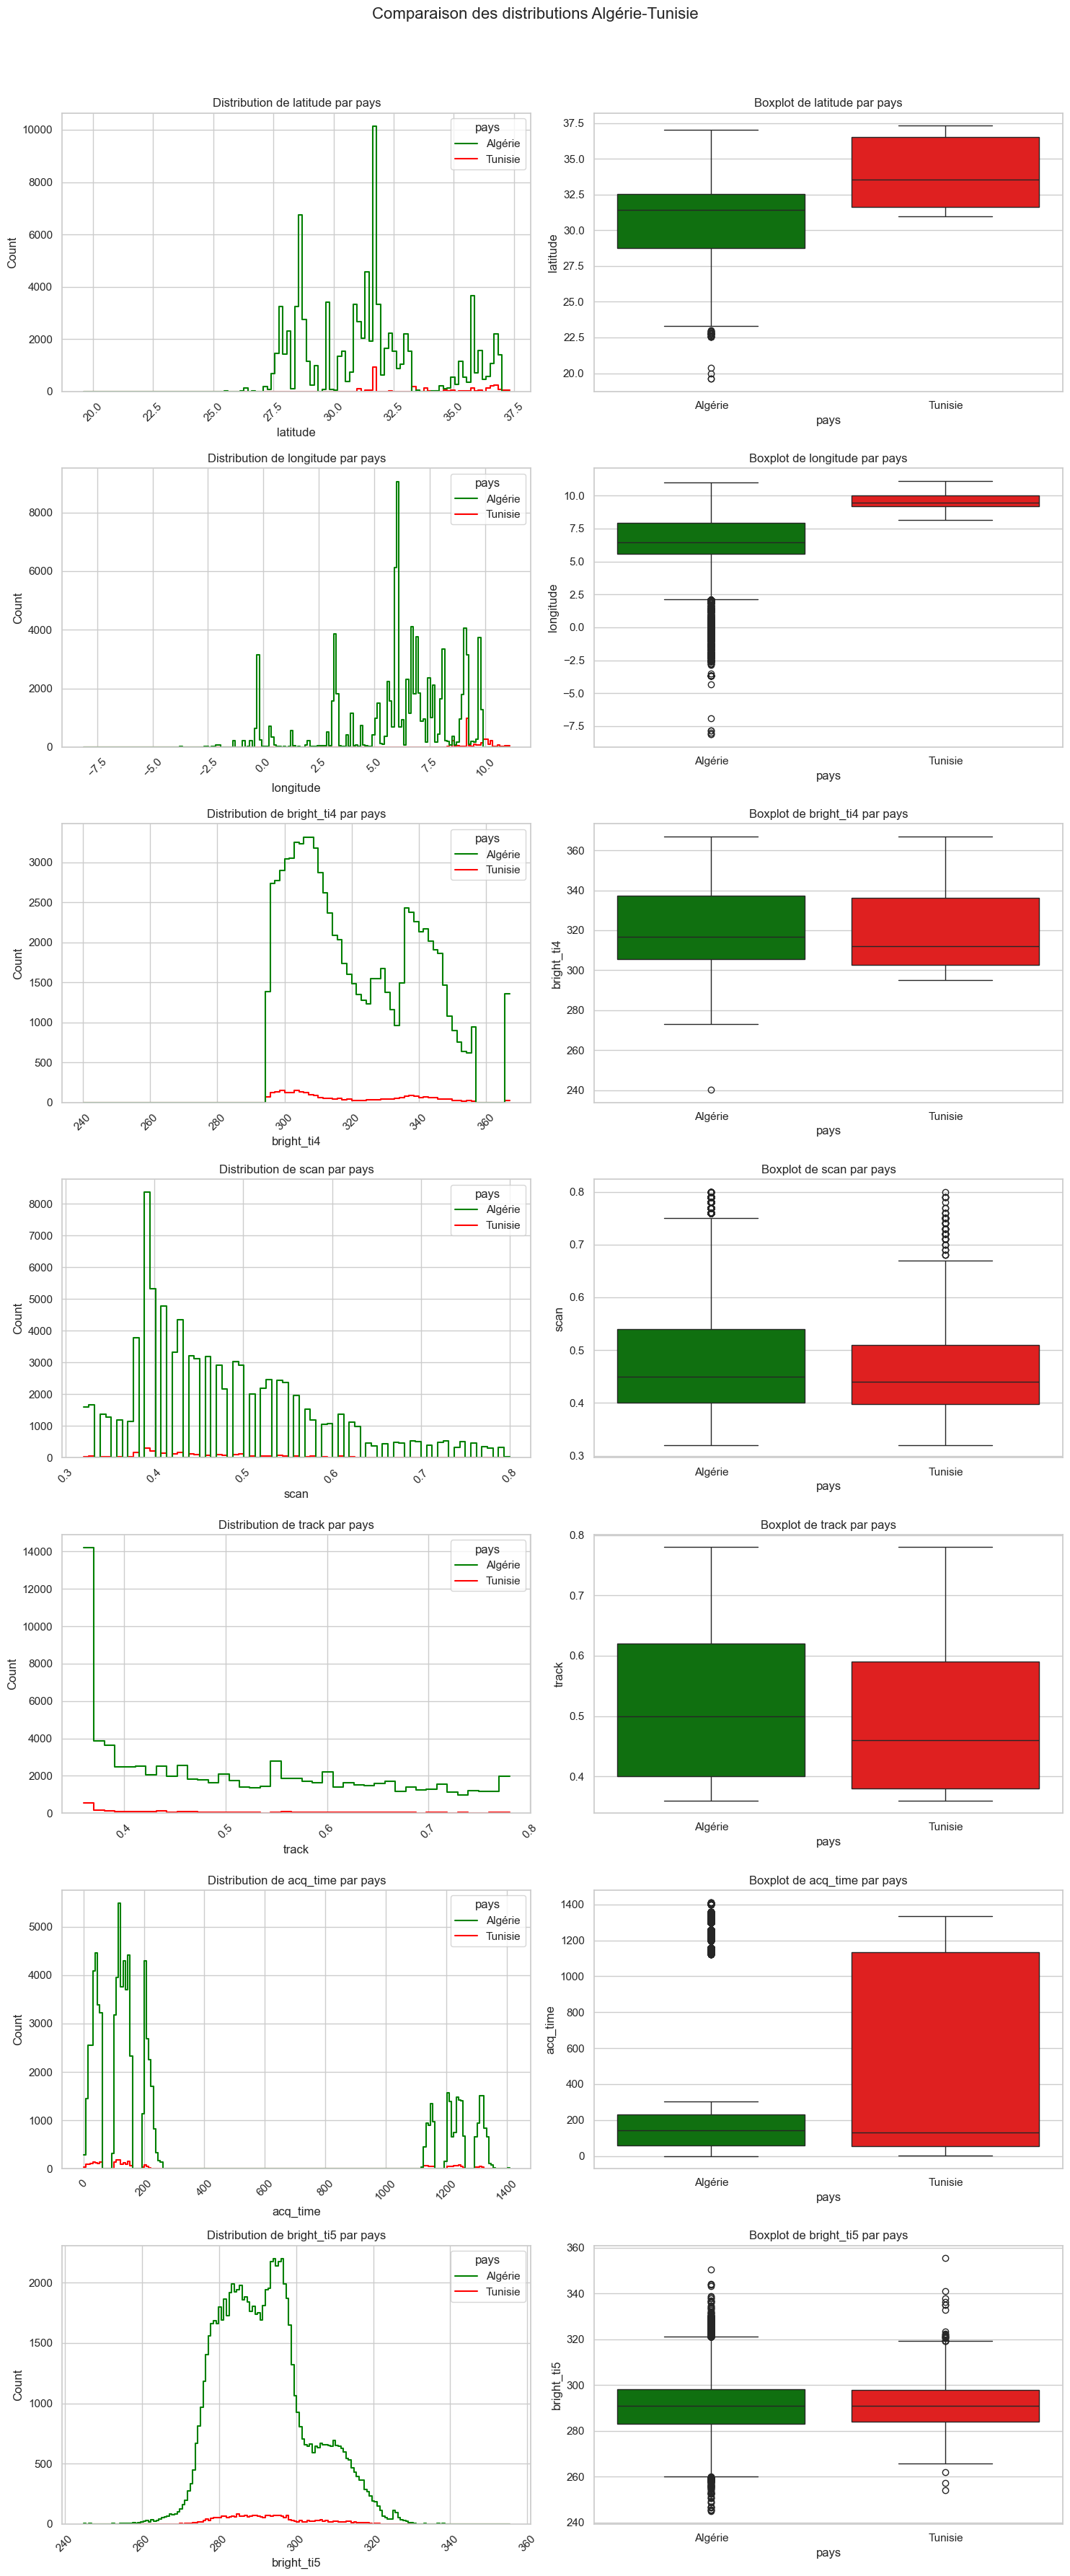

In [5]:
# Préparation des données pour la comparaison
# Ajout d'une colonne 'pays' pour identifier l'origine des données
algeria_fires['pays'] = 'Algérie'
tunisia_fires['pays'] = 'Tunisie'

# Combiner les deux datasets
combined_fires = pd.concat([algeria_fires, tunisia_fires])

# Fonction pour créer des visualisations comparatives
def plot_comparative_distributions(df, numeric_columns):
    # Exclure les colonnes spécifiées
    columns_to_exclude = ['version', 'frp', 'type']
    numeric_columns = [col for col in numeric_columns if col not in columns_to_exclude]
    n_cols = len(numeric_columns)
    
    # Définir les couleurs
    colors = {'Algérie': 'green', 'Tunisie': 'red'}
    
    # Création des subplots
    fig, axes = plt.subplots(n_cols, 2, figsize=(15, 5*n_cols))
    fig.suptitle('Comparaison des distributions Algérie-Tunisie', y=1.02, fontsize=16)
    
    # Si une seule colonne, convertir axes en tableau 2D
    if n_cols == 1:
        axes = np.array([axes])
    
    for i, col in enumerate(numeric_columns):
        # Histogramme sans KDE pour éviter les erreurs
        sns.histplot(data=df, x=col, hue='pays', ax=axes[i,0], 
                    element="step", fill=False,
                    palette=colors)
        axes[i,0].set_title(f'Distribution de {col} par pays')
        axes[i,0].tick_params(axis='x', rotation=45)
        
        # Boxplot avec hue au lieu de palette
        sns.boxplot(data=df, y=col, hue='pays', x='pays', ax=axes[i,1],
                   palette=colors, legend=False)
        axes[i,1].set_title(f'Boxplot de {col} par pays')
    
    plt.tight_layout()
    plt.show()

# Sélection des colonnes numériques communes
numeric_cols = combined_fires.select_dtypes(include=['float64', 'int64']).columns
plot_comparative_distributions(combined_fires, numeric_cols)

# 4 - Analyse bivariée

Correlation matrix, scatterplots and heatmaps between numeric variables.

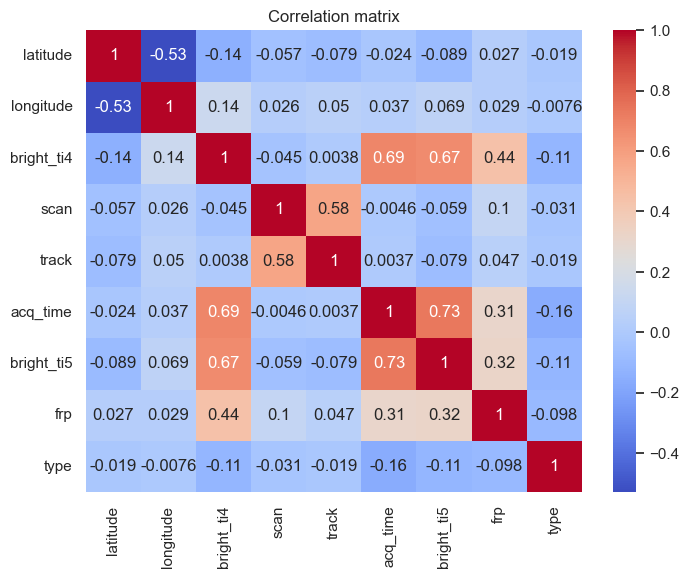

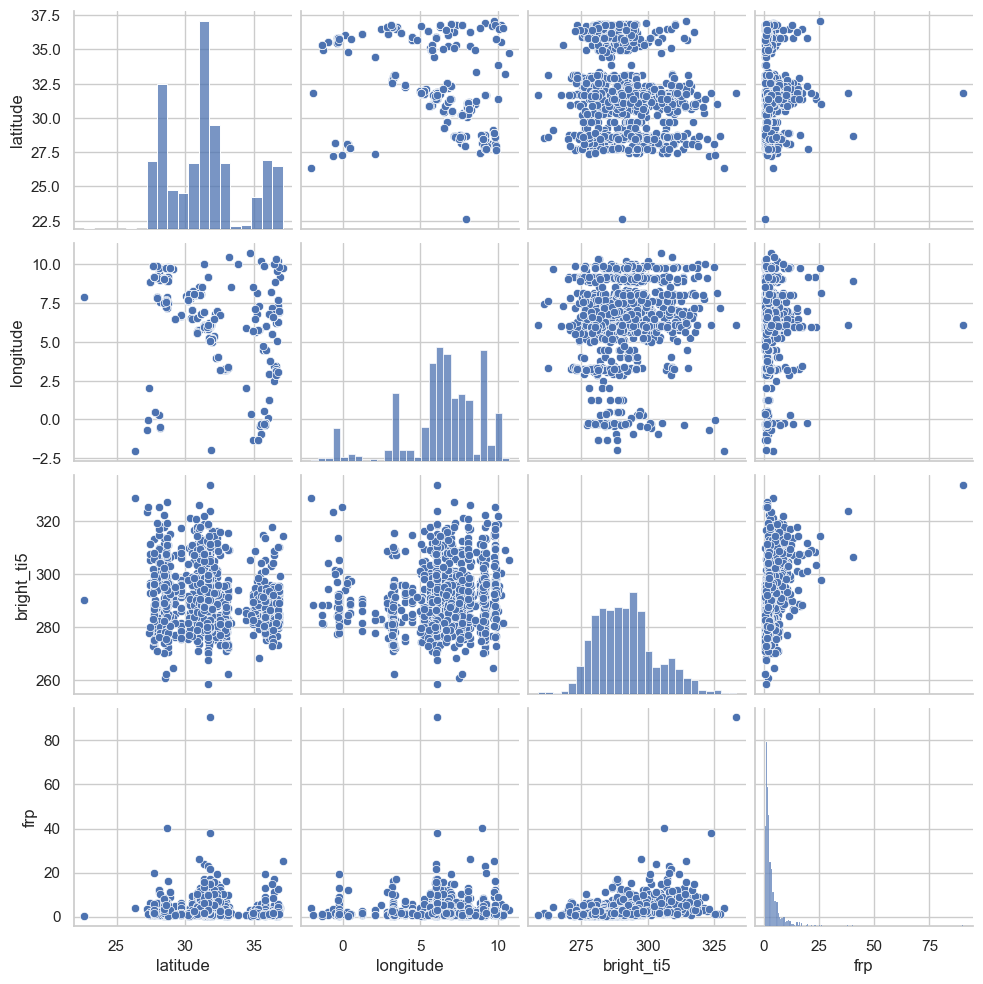

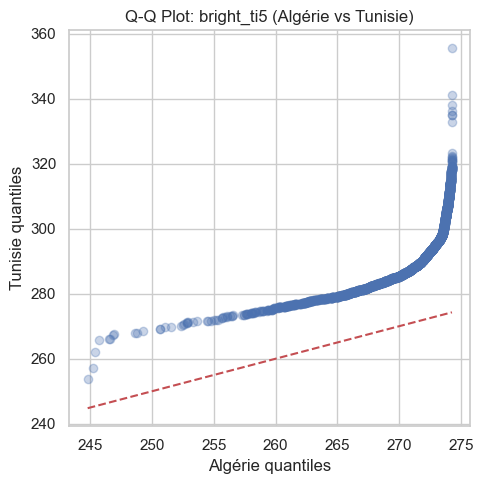

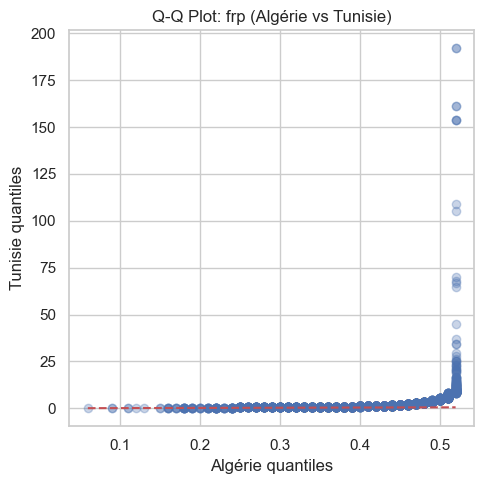

In [6]:
def qq_compare(df, country_col='pays', features=['bright_ti5', 'frp']):
    countries = df[country_col].unique()
    if len(countries) < 2:
        print("Need at least two countries for Q-Q comparison.")
        return
    c1, c2 = countries[:2]
    for feat in features:
        if feat not in df.columns:
            continue
        data1 = df[df[country_col] == c1][feat].dropna()
        data2 = df[df[country_col] == c2][feat].dropna()
        min_len = min(len(data1), len(data2))
        if min_len == 0:
            continue
        # Sort and align quantiles
        q1 = np.sort(data1)[:min_len]
        q2 = np.sort(data2)[:min_len]
        plt.figure(figsize=(5,5))
        plt.scatter(q1, q2, alpha=0.3)
        plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--')
        plt.xlabel(f'{c1} quantiles')
        plt.ylabel(f'{c2} quantiles')
        plt.title(f'Q-Q Plot: {feat} ({c1} vs {c2})')
        plt.tight_layout()
        plt.show()


def plot_bivariate(df, exclude_cols=None):
    if df is None:
        return
    if exclude_cols is None:
        exclude_cols = []
    numeric = df.select_dtypes(include=['number']).columns
    numeric = [c for c in numeric if c not in exclude_cols]
    if len(numeric) < 2:
        print('Not enough numeric columns for bivariate plots')
        return
    
    # Correlation matrix
    corr = df[numeric].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation matrix')
    plt.show()
    # Select only relevant features for pairwise scatter
    relevant_features = ['latitude', 'longitude', 'bright_ti5', 'frp']

    # Pairwise scatter (sample if large)
    sample = df[relevant_features].dropna()
    if sample.shape[0] > 1000:
        sample = sample.sample(1000, random_state=0)
    sns.pairplot(sample)
    plt.show()

    # Q-Q plots
    qq_compare(combined_fires, features=['bright_ti5', 'frp'])

    
plot_bivariate(pd.concat([algeria_fires,tunisia_fires], ignore_index=True), exclude_cols=["version"])

# Distribution of the fire types

Original Data:


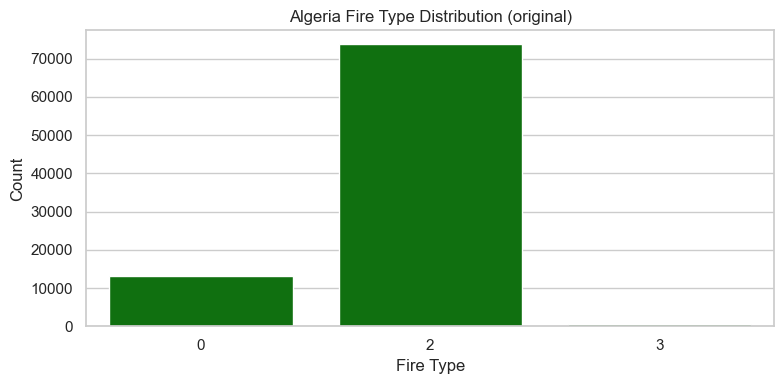


Algeria fire type counts:
type
0    13216
2    73694
3      536
Name: count, dtype: int64


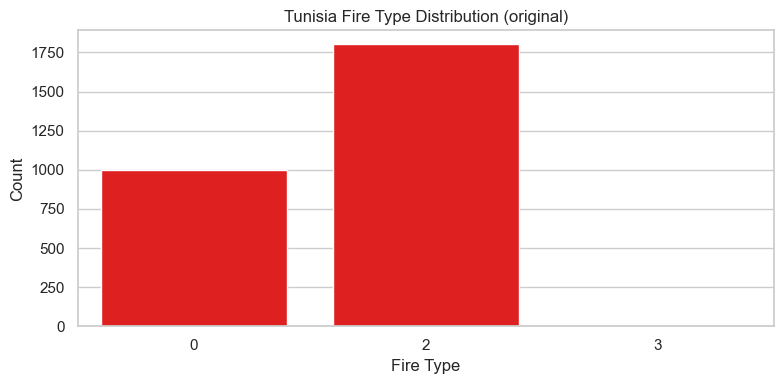


Tunisia fire type counts:
type
0    1000
2    1801
3       3
Name: count, dtype: int64


In [7]:
def plot_fire_type_distribution(df, country_name, color, title_suffix=''):
    if df is None or 'type' not in df.columns:
        print(f'No type column in {country_name} dataset')
        return
    type_counts = df['type'].value_counts().sort_index()
    plt.figure(figsize=(8,4))
    sns.barplot(x=type_counts.index, y=type_counts.values, color=color)
    plt.title(f'{country_name} Fire Type Distribution {title_suffix}')
    plt.xlabel('Fire Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    # Print actual counts
    print(f"\n{country_name} fire type counts:")
    print(type_counts)

# 1) Original datasets (separate plots)
print("Original Data:")
plot_fire_type_distribution(algeria_fires, 'Algeria', 'green', '(original)')
plot_fire_type_distribution(tunisia_fires, 'Tunisia', 'red', '(original)')

# 5 - Analyse Temporelle

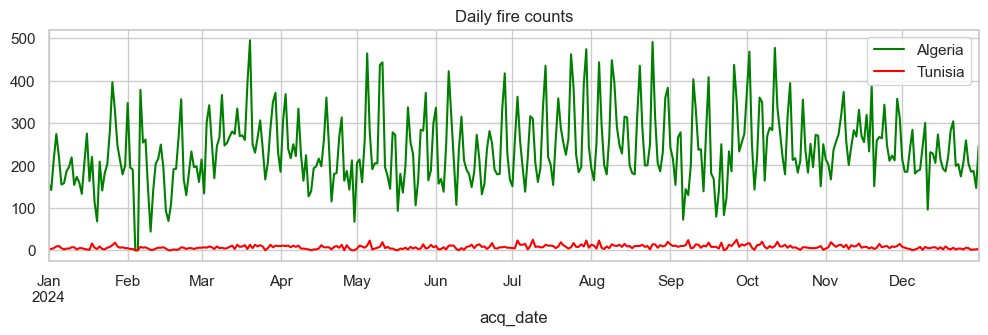

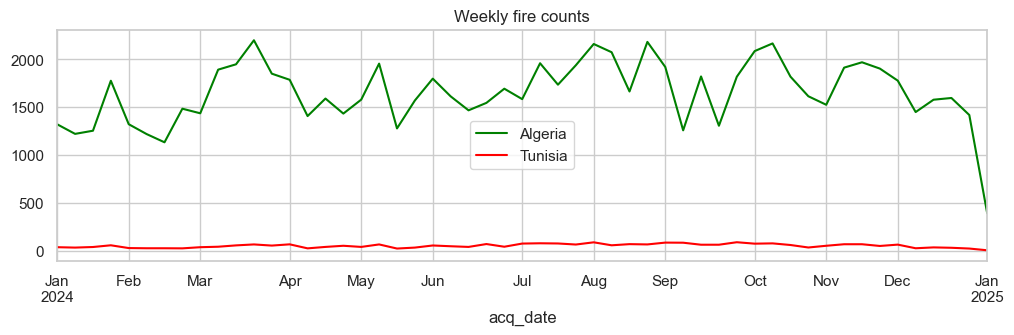

In [8]:
def temporal_analysis_dual(df1, df2, label1='Algeria', label2='Tunisia', date_col_candidates=['acq_date','acq_datetime','date','time']):
    # Find date column for each
    def get_date_col(df):
        for c in date_col_candidates:
            if c in df.columns:
                return c
        return None
    col1 = get_date_col(df1)
    col2 = get_date_col(df2)
    if col1 is None or col2 is None:
        print('No date column found in one of the datasets')
        return
    d1 = df1.copy()
    d2 = df2.copy()
    d1[col1] = pd.to_datetime(d1[col1], errors='coerce')
    d2[col2] = pd.to_datetime(d2[col2], errors='coerce')
    d1 = d1.dropna(subset=[col1]).set_index(col1)
    d2 = d2.dropna(subset=[col2]).set_index(col2)
    # Daily counts
    c1 = d1.resample('D').size()
    c2 = d2.resample('D').size()
    plt.figure(figsize=(12,3))
    c1.plot(label=label1, color='green')
    c2.plot(label=label2, color='red')
    plt.title('Daily fire counts')
    plt.legend()
    plt.show()
    # Weekly counts
    w1 = d1.resample('W').size()
    w2 = d2.resample('W').size()
    plt.figure(figsize=(12,3))
    w1.plot(label=label1, color='green')
    w2.plot(label=label2, color='red')
    plt.title('Weekly fire counts')
    plt.legend()
    plt.show()

# Example
# temporal_analysis_dual(algeria_clean, tunisia_clean)
temporal_analysis_dual(algeria_fires, tunisia_fires, label1='Algeria', label2='Tunisia')


# 6 - Analyse Spatiale

Original data:
Algeria: (87446, 16)
Tunisia: (2804, 16)


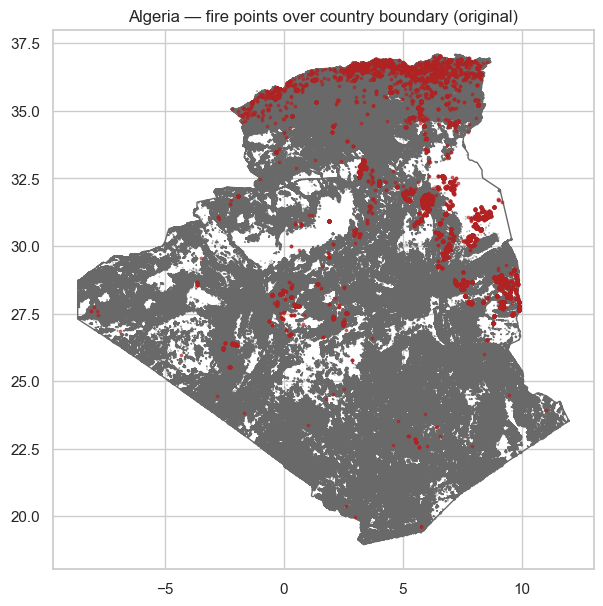

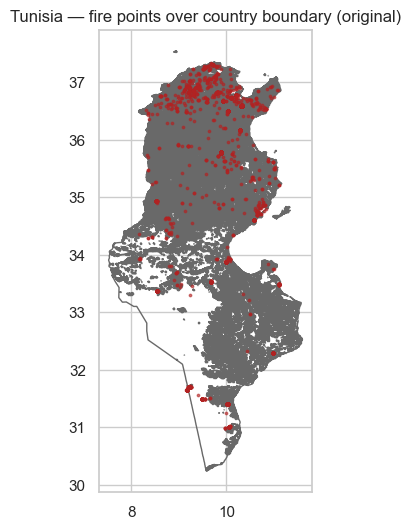

In [9]:
# load landcover data of algeria and tunisia using config paths
algeria_lc = gpd.read_file(ALGERIA_SHP)
tunisia_lc = gpd.read_file(TUNISIA_SHP)

# create geodataframes for fire points
def clean_fire_df(df, country_name):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs='EPSG:4326'
    )
    return gdf

print("Original data:")
print('Algeria:', algeria_fires.shape)
print('Tunisia:', tunisia_fires.shape)

# Create geodataframes for original data
alg_gdf = clean_fire_df(algeria_fires, 'Algeria')
tn_gdf = clean_fire_df(tunisia_fires, 'Tunisia')

# Plot Algeria - fire points over country boundary (original)
fig, ax = plt.subplots(figsize=(7,7))
algeria_lc.plot(ax=ax, edgecolor='dimgray', facecolor='none')
alg_gdf.plot(ax=ax, markersize=3, color='firebrick', alpha=0.6)
plt.title('Algeria — fire points over country boundary (original)')
plt.show()

# Plot Tunisia - fire points over country boundary (original)
fig, ax = plt.subplots(figsize=(6,6))
tunisia_lc.plot(ax=ax, edgecolor='dimgray', facecolor='none')
tn_gdf.plot(ax=ax, markersize=3, color='firebrick', alpha=0.6)
plt.title('Tunisia — fire points over country boundary (original)')
plt.show()

# 7 - Data Preprocessing

Includes cleaning (missing values, duplicates, outliers) and clipping utilities.

In [10]:
print("="*80)
print("DATA PREPROCESSING PIPELINE")
print("="*80)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def exclude_type_2_fires(df, verbose=True):
    """Keep only type 0 fires from dataset."""
    if df is None or 'type' not in df.columns:
        return df
    
    if verbose:
        print(f"Before: {len(df)} rows")
        print(f"Fire types distribution before filtering:")
        print(df['type'].value_counts().sort_index())
    
    df_clean = df[df['type'] == 0].copy()
    
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {len(df) - len(df_clean)} rows with type != 0")
    
    return df_clean


def drop_duplicates_from_df(df, verbose=True):
    """Remove duplicate rows."""
    if df is None:
        return df
    
    if verbose:
        duplicates_count = df.duplicated().sum()
        print(f"Before: {len(df)} rows")
    df_clean = df.drop_duplicates()
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {duplicates_count} duplicate rows")
    return df_clean


def fill_missing_values(df, verbose=True):
    """Fill missing values based on column type."""
    if df is None:
        return df
    
    df_clean = df.copy()
    
    # Check initial missing values
    if verbose:
        missing_before = df_clean.isnull().sum()
        if missing_before.sum() > 0:
            print("\nMissing values per column BEFORE filling:")
            print(missing_before[missing_before > 0])
    
    # Identify column types
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    date_cols = []
    categorical_cols = []
    
    for col in df_clean.columns:
        if col in numeric_cols:
            continue
        if 'date' in col.lower() or 'time' in col.lower():
            date_cols.append(col)
        else:
            categorical_cols.append(col)
    
    if verbose:
        print(f"\nColumn types identified:")
        print(f"  Numeric: {numeric_cols}")
        print(f"  Date: {date_cols}")
        print(f"  Categorical: {categorical_cols}")
    
    # Fill numeric columns with MEDIAN
    if numeric_cols:
        if verbose:
            print("\nFilling numeric columns with MEDIAN...")
        for col in numeric_cols:
            if df_clean[col].isnull().sum() > 0:
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                if verbose:
                    print(f"  {col}: filled with {median_val}")
    
    # Fill date columns with INTERPOLATION
    if date_cols:
        if verbose:
            print("\nFilling date columns with INTERPOLATION...")
        for col in date_cols:
            if df_clean[col].isnull().sum() > 0:
                df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
                df_clean[col] = pd.to_datetime(
                    df_clean[col].astype(np.int64).interpolate(method='linear').astype(np.int64),
                    errors='coerce'
                )
                df_clean[col].ffill(inplace=True)
                df_clean[col].bfill(inplace=True)
                if verbose:
                    print(f"  {col}: interpolated")
    
    # Fill categorical columns with MODE
    if categorical_cols:
        if verbose:
            print("\nFilling categorical columns with MODE...")
        for col in categorical_cols:
            if df_clean[col].isnull().sum() > 0:
                mode_val = df_clean[col].mode()
                if len(mode_val) > 0:
                    df_clean[col].fillna(mode_val[0], inplace=True)
                    if verbose:
                        print(f"  {col}: filled with '{mode_val[0]}'")
    
    return df_clean


def add_class_column(df, class_value=1, verbose=True):
    """Add class column with specified value."""
    if df is None:
        return df
    
    df_clean = df.copy()
    df_clean['class'] = class_value
    if verbose:
        print(f"Column 'class' added with value {class_value}. Shape: {df_clean.shape}")
    return df_clean


def filter_by_latitude(df, min_latitude=33, verbose=True):
    """Remove rows with latitude below threshold."""
    if df is None or 'latitude' not in df.columns:
        return df
    
    if verbose:
        print(f"Before: {len(df)} rows")
        print(f"Latitude range before: [{df['latitude'].min():.2f}, {df['latitude'].max():.2f}]")
    
    rows_below = (df['latitude'] < min_latitude).sum()
    df_clean = df[df['latitude'] >= min_latitude].copy()
    
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {rows_below} rows with latitude < {min_latitude}")
        print(f"Latitude range after: [{df_clean['latitude'].min():.2f}, {df_clean['latitude'].max():.2f}]")
    
    return df_clean


def replace_outliers(df, exclude_cols=['latitude', 'longitude', 'class'], verbose=True):
    """Replace outliers using IQR method."""
    if df is None:
        return df
    
    df_clean = df.copy()
    
    # Get numeric columns (excluding specified columns)
    numeric_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns 
                    if col not in exclude_cols]
    
    if verbose and numeric_cols:
        print(f"\nAnalyzing outliers in: {numeric_cols}")
    
    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        outliers_count = outliers_mask.sum()
        
        if outliers_count > 0:
            median_val = df_clean[col].median()
            df_clean.loc[outliers_mask, col] = median_val
            if verbose:
                print(f"  {col}: Replaced {outliers_count} outliers ({100*outliers_count/len(df_clean):.2f}%) with median {median_val:.2f}")
    
    # Handle categorical columns
    categorical_cols = [col for col in df_clean.select_dtypes(include=['object']).columns]
    if categorical_cols and verbose:
        print(f"\nCategorical columns (using mode for rare values): {categorical_cols}")
    
    for col in categorical_cols:
        value_counts = df_clean[col].value_counts()
        rare_threshold = len(df_clean) * 0.01
        rare_values = value_counts[value_counts < rare_threshold].index
        
        if len(rare_values) > 0:
            mode_val = df_clean[col].mode()[0]
            rare_mask = df_clean[col].isin(rare_values)
            df_clean.loc[rare_mask, col] = mode_val
            if verbose:
                print(f"  {col}: Replaced {rare_mask.sum()} rare values with mode '{mode_val}'")
    
    return df_clean


def keep_columns(df, columns_to_keep, verbose=True):
    """Keep only specified columns."""
    if df is None:
        return df
    
    if verbose:
        print(f"Before: {df.shape[1]} columns")
    
    available_cols = [col for col in columns_to_keep if col in df.columns]
    df_clean = df[available_cols].copy()
    
    if verbose:
        print(f"After: {df_clean.shape[1]} columns")
        print(f"Columns kept: {available_cols}")
    
    return df_clean


def preprocess_dataset(df, name='Dataset', min_latitude=33, keep_cols=['longitude', 'latitude', 'class'], verbose=True):
    """
    Complete preprocessing pipeline for a single dataset.
    Returns cleaned dataframe.
    """
    if df is None:
        return None
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"PREPROCESSING: {name}")
        print(f"{'='*60}")
        print(f"Initial shape: {df.shape}")
    
    # Apply preprocessing steps
    df_clean = exclude_type_2_fires(df, verbose=verbose)
    df_clean = drop_duplicates_from_df(df_clean, verbose=verbose)
    df_clean = fill_missing_values(df_clean, verbose=verbose)
    df_clean = add_class_column(df_clean, class_value=1, verbose=verbose)
    df_clean = filter_by_latitude(df_clean, min_latitude=min_latitude, verbose=verbose)
    df_clean = replace_outliers(df_clean, verbose=verbose)
    df_clean = keep_columns(df_clean, columns_to_keep=keep_cols, verbose=verbose)
    
    if verbose:
        print(f"\nFinal shape: {df_clean.shape}")
        print(f"{'='*60}\n")
    
    return df_clean


# ============================================================================
# MAIN PREPROCESSING
# ============================================================================

# Set latitude threshold
latitude_bound = 33

print("\n" + "="*80)
print("PREPROCESSING INDIVIDUAL DATASETS")
print("="*80)

# Preprocess Algeria dataset
algeria_clean = preprocess_dataset(
    algeria_fires, 
    name='Algeria',
    min_latitude=latitude_bound,
    keep_cols=['longitude', 'latitude', 'class'],
    verbose=True
)

# Preprocess Tunisia dataset
tunisia_clean = preprocess_dataset(
    tunisia_fires,
    name='Tunisia',
    min_latitude=latitude_bound,
    keep_cols=['longitude', 'latitude', 'class'],
    verbose=True
)

print("\n" + "="*80)
print("PREPROCESSING COMBINED DATASET")
print("="*80)

# ============================================================================
# STEP 1: Concatenate Algeria and Tunisia datasets
# ============================================================================
print("\n[STEP 1] Concatenating Algeria and Tunisia datasets...")
combined_fires = pd.concat([algeria_fires, tunisia_fires], ignore_index=True)
print(f"Combined dataset shape: {combined_fires.shape}")
print(f"Fire types distribution:")
print(combined_fires['type'].value_counts().sort_index())

# ============================================================================
# Apply preprocessing pipeline to combined dataset
# ============================================================================
combined_fires_final = preprocess_dataset(
    combined_fires,
    name='Combined Dataset',
    min_latitude=latitude_bound,
    keep_cols=['longitude', 'latitude', 'class'],
    verbose=True
)

# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n[FINAL STEP] Saving results...")
combined_fires_final.to_csv(FIRES_RESULT_CSV, index=False)
print(f"Dataset saved to: {FIRES_RESULT_CSV}")
print(f"File contains {len(combined_fires_final)} rows and {len(combined_fires_final.columns)} columns")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("PREPROCESSING COMPLETE - SUMMARY")
print("="*80)
print(f"Algeria cleaned:               {len(algeria_clean):,} rows")
print(f"Tunisia cleaned:               {len(tunisia_clean):,} rows")
print(f"Combined cleaned (fires.csv):  {len(combined_fires_final):,} rows")
print(f"\nOriginal total:                {len(algeria_fires) + len(tunisia_fires):,} rows")
print(f"Final total:                   {len(combined_fires_final):,} rows")
print(f"Total rows removed:            {(len(algeria_fires) + len(tunisia_fires)) - len(combined_fires_final):,} rows")
print(f"Retention rate:                {100*len(combined_fires_final)/(len(algeria_fires) + len(tunisia_fires)):.2f}%")
print("\nColumns in final datasets: longitude, latitude, class")
print("="*80)

# Display previews
print("\nPreview of Algeria cleaned:")
display(algeria_clean.head())

print("\nPreview of Tunisia cleaned:")
display(tunisia_clean.head())

print("\nPreview of combined fires.csv:")
display(combined_fires_final.head(10))

DATA PREPROCESSING PIPELINE

PREPROCESSING INDIVIDUAL DATASETS

PREPROCESSING: Algeria
Initial shape: (87446, 16)
Before: 87446 rows
Fire types distribution before filtering:
type
0    13216
2    73694
3      536
Name: count, dtype: int64
After: 13216 rows
Removed: 74230 rows with type != 0
Before: 13216 rows
After: 13216 rows
Removed: 0 duplicate rows

Column types identified:
  Numeric: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_time', 'version', 'bright_ti5', 'frp', 'type']
  Date: ['acq_date']
  Categorical: ['satellite', 'instrument', 'confidence', 'daynight', 'pays']

Filling numeric columns with MEDIAN...

Filling date columns with INTERPOLATION...

Filling categorical columns with MODE...
Column 'class' added with value 1. Shape: (13216, 17)
Before: 13216 rows
Latitude range before: [19.60, 37.02]
After: 2457 rows
Removed: 10759 rows with latitude < 33
Latitude range after: [33.02, 37.02]

Analyzing outliers in: ['bright_ti4', 'scan', 'track', 'acq_time', 've

,longitude,latitude,class
5,5.53337,35.70751,1
166,2.46763,36.49380,1
167,2.47313,36.49316,1
168,2.46726,36.49249,1
169,2.47275,36.49182,1



Preview of Tunisia cleaned:


,longitude,latitude,class
11,10.09115,36.93407,1
12,10.02415,36.50442,1
19,9.81787,34.87574,1
20,10.55455,36.57825,1
21,10.02436,36.50443,1



Preview of combined fires.csv:


,longitude,latitude,class
5,5.53337,35.70751,1
166,2.46763,36.49380,1
167,2.47313,36.49316,1
168,2.46726,36.49249,1
169,2.47275,36.49182,1
189,-0.26469,35.62561,1
286,5.10458,34.66615,1
296,2.47095,36.49013,1
297,2.47010,36.49344,1
309,2.47038,36.49175,1


# 8 - Merging

In [11]:
print("="*80)
print("ADDING ARTIFICIAL NON-FIRE DATA (CLASS 0)")
print("="*80)

# ============================================================================
# STEP 1: Load fires.csv
# ============================================================================
print("\n[STEP 1] Loading fires.csv...")
fires_df = pd.read_csv(FIRES_RESULT_CSV)

print(f"Loaded fires dataset:")
print(f"  Shape: {fires_df.shape}")
print(f"  Columns: {list(fires_df.columns)}")
print(f"\nOriginal data statistics:")
print(fires_df.describe())

print(f"\nClass distribution BEFORE adding artificial data:")
print(fires_df['class'].value_counts().sort_index())

# ============================================================================
# STEP 2: Analyze current data ranges
# ============================================================================
print("\n[STEP 2] Analyzing current data ranges...")
lon_min, lon_max = fires_df['longitude'].min(), fires_df['longitude'].max()
lat_min, lat_max = fires_df['latitude'].min(), fires_df['latitude'].max()

print(f"  Longitude range: [{lon_min:.5f}, {lon_max:.5f}]")
print(f"  Latitude range: [{lat_min:.5f}, {lat_max:.5f}]")

# Ensure latitude >= latitude_bound constraint
if lat_min < latitude_bound:
    lat_min = latitude_bound
    print(f"  Adjusted latitude min to: {lat_min} (respecting constraint)")

# ============================================================================
# STEP 3: Generate artificial non-fire data (class 0)
# ============================================================================
print("\n[STEP 3] Generating artificial non-fire data (class 0)...")

# Set random seed for reproducibility
np.random.seed(42)

# Number of artificial samples to generate (1.5 class 1 for balanced dataset)
num_artificial = int(1.5 * len(fires_df))
print(f"  Generating {num_artificial} artificial samples (1.5 times class 1 count)...")

# Generate random coordinates within the valid ranges
artificial_longitudes = np.random.uniform(lon_min, lon_max, num_artificial)
artificial_latitudes = np.random.uniform(lat_min, lat_max, num_artificial)

# Round to 5 decimal places to match original data format
artificial_longitudes = np.round(artificial_longitudes, 5)
artificial_latitudes = np.round(artificial_latitudes, 5)

# Create artificial dataframe with class 0
artificial_df = pd.DataFrame({
    'longitude': artificial_longitudes,
    'latitude': artificial_latitudes,
    'class': 0
})

print(f"  Artificial data shape: {artificial_df.shape}")
print(f"\nArtificial data statistics:")
print(artificial_df.describe())

print(f"\nSample of artificial coordinates (first 5):")
print(artificial_df.head())

# ============================================================================
# STEP 4: Combine real fire data (class 1) with artificial data (class 0)
# ============================================================================
print("\n[STEP 4] Combining real fire data with artificial non-fire data...")
print(f"  Real fire data (class 1): {len(fires_df)} rows")
print(f"  Artificial data (class 0): {len(artificial_df)} rows")

# Concatenate the datasets
fires_with_artificial = pd.concat([fires_df, artificial_df], ignore_index=True)

print(f"\nCombined dataset shape: {fires_with_artificial.shape}")

# ============================================================================
# STEP 5: Shuffle the dataset
# ============================================================================
print("\n[STEP 5] Shuffling the combined dataset...")
fires_with_artificial = fires_with_artificial.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"  Dataset shuffled with random_state=42")

# ============================================================================
# STEP 6: Verify the final dataset
# ============================================================================
print("\n[STEP 6] Verifying final dataset...")
print(f"\nFinal dataset shape: {fires_with_artificial.shape}")
print(f"Final columns: {list(fires_with_artificial.columns)}")

print(f"\nClass distribution AFTER adding artificial data:")
class_counts = fires_with_artificial['class'].value_counts().sort_index()
print(class_counts)
print(f"\nClass balance:")
for cls in class_counts.index:
    pct = 100 * class_counts[cls] / len(fires_with_artificial)
    class_name = "non-fire" if cls == 0 else "fire"
    print(f"  Class {cls} ({class_name}): {class_counts[cls]} rows ({pct:.2f}%)")

print(f"\nClass ratio (class 0 : class 1) = {class_counts[0]} : {class_counts[1]} (1:1 balanced)")

print(f"\nFinal data ranges:")
print(f"  Longitude: [{fires_with_artificial['longitude'].min():.5f}, {fires_with_artificial['longitude'].max():.5f}]")
print(f"  Latitude: [{fires_with_artificial['latitude'].min():.5f}, {fires_with_artificial['latitude'].max():.5f}]")

# Verify latitude constraint
min_lat = fires_with_artificial['latitude'].min()
if min_lat < latitude_bound:
    print(f"\n  ⚠️ WARNING: Some latitudes are below {latitude_bound} (min: {min_lat:.5f})")
else:
    print(f"\n  ✓ All latitudes >= {latitude_bound} (min: {min_lat:.5f})")

print("\nFinal dataset statistics:")
print(fires_with_artificial.describe())

# ============================================================================
# STEP 7: Save the combined dataset
# ============================================================================
print("\n[STEP 7] Saving the combined dataset...")
fires_with_artificial.to_csv(FIRES_RESULT_CSV, index=False)
print(f"  Dataset saved to: {FIRES_RESULT_CSV}")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SUMMARY - BALANCED DATASET GENERATION")
print("="*80)
print(f"Original fire data (class 1):        {len(fires_df):,} rows")
print(f"Artificial non-fire data (class 0):  {num_artificial:,} rows")
print(f"Total combined dataset:              {len(fires_with_artificial):,} rows")
print(f"\nRatio: 1:1 (class 0 : class 1)")
print(f"Dataset saved to: {FIRES_RESULT_CSV}")
print(f"Coordinates precision: 5 decimal places (matching original data)")
print(f"Ready for feature extraction (climate, elevation, soil)!")
print("="*80)

# Display preview
print("\nPreview of combined dataset (first 10 rows):")
display(fires_with_artificial.head(10))
print("\nPreview of combined dataset (last 10 rows):")
display(fires_with_artificial.tail(10))

ADDING ARTIFICIAL NON-FIRE DATA (CLASS 0)

[STEP 1] Loading fires.csv...
Loaded fires dataset:
  Shape: (3285, 3)
  Columns: ['longitude', 'latitude', 'class']

Original data statistics:
         longitude     latitude   class
count  3285.000000  3285.000000  3285.0
mean      5.794025    35.970245     1.0
std       3.200867     0.960607     0.0
min      -2.181140    33.016400     1.0
25%       3.619850    35.489050     1.0
50%       5.988160    36.372790     1.0
75%       8.351790    36.661970     1.0
max      11.110350    37.323460     1.0

Class distribution BEFORE adding artificial data:
class
1    3285
Name: count, dtype: int64

[STEP 2] Analyzing current data ranges...
  Longitude range: [-2.18114, 11.11035]
  Latitude range: [33.01640, 37.32346]

[STEP 3] Generating artificial non-fire data (class 0)...
  Generating 4927 artificial samples (1.5 times class 1 count)...
  Artificial data shape: (4927, 3)

Artificial data statistics:
         longitude     latitude   class
count  49

,longitude,latitude,class
0,9.42603,37.00734,1
1,0.84846,36.48433,0
2,4.13116,36.62614,1
3,7.28408,36.89190,1
4,8.46453,35.31460,0
5,4.65055,36.84538,0
6,5.36770,37.17534,0
7,1.42549,36.16594,0
8,4.11798,33.48140,0
9,0.87602,36.50915,0



Preview of combined dataset (last 10 rows):


,longitude,latitude,class
8202,7.24784,35.10395,1
8203,4.68488,37.09120,0
8204,2.44176,33.47648,0
8205,3.87698,35.72507,1
8206,3.63603,36.44511,0
8207,2.37050,35.28756,0
8208,10.55308,36.97253,0
8209,2.02909,35.53938,0
8210,2.02568,34.22094,1
8211,10.18524,36.77415,0


In [12]:
# load fires.csv to verify
loaded_df = pd.read_csv(FIRES_RESULT_CSV)

# Clip all rows to 5 decimal places
loaded_df = loaded_df.round(5)

# save in a new file
loaded_df.to_csv(FIRES_WITH_ARTIFICIAL, index=False)
print(f"Saved clipped data to: {FIRES_WITH_ARTIFICIAL}")

Saved clipped data to: C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_artificial_clipped.csv


⚠️ **WARNING**: Run the following cells **only after** executing:
- `soil.ipynb`
- `elevation.ipynb`
- `climate.ipynb`

These notebooks must be completed first to generate the required feature datasets.

In [22]:
print("="*80)
print("REMOVING SEA POINTS FROM ALL DATASETS")
print("="*80)

# ============================================================================
# STEP 1: Load fires_with_soil_features.csv
# ============================================================================
print("\n[STEP 1] Loading fires_with_soil_features.csv...")
soil_df = pd.read_csv(FIRES_WITH_SOIL)

print(f"Loaded soil features dataset:")
print(f"  Shape: {soil_df.shape}")
print(f"  Columns: {list(soil_df.columns)}")

# ============================================================================
# STEP 2: Identify sea points (class=0 with empty soil features)
# ============================================================================
print("\n[STEP 2] Identifying sea points...")

# Identify soil feature columns (excluding longitude, latitude, class)
soil_feature_cols = [col for col in soil_df.columns 
                     if col not in ['longitude', 'latitude', 'class']]

print(f"Soil feature columns: {soil_feature_cols}")

# Find rows where class=0 AND all soil features are empty (,,,,)
sea_mask = (soil_df['class'] == 0) & (soil_df[soil_feature_cols].isna().all(axis=1))
sea_points = soil_df[sea_mask][['longitude', 'latitude']].copy()

print(f"\nSea points identified: {len(sea_points)} rows")
print(f"  (class=0 with all soil features empty)")

# ============================================================================
# STEP 3: Save sea points to sea.csv
# ============================================================================
print("\n[STEP 3] Saving sea points to sea.csv...")
sea_points.to_csv(SEA_CSV, index=False)
print(f"  Sea points saved to: {SEA_CSV}")

print("\nSample of sea points (first 5):")
display(sea_points.head())

# ============================================================================
# STEP 4: Remove sea points from fires_with_soil_features.csv
# ============================================================================
print("\n[STEP 4] Removing sea points from fires_with_soil_features.csv...")
print(f"  Before: {len(soil_df)} rows")

soil_df_clean = soil_df[~sea_mask].copy()

print(f"  After: {len(soil_df_clean)} rows")
print(f"  Removed: {len(soil_df) - len(soil_df_clean)} sea points")

# Save cleaned soil features
soil_df_clean.to_csv(FIRES_WITH_SOIL, index=False)
print(f"  Updated fires_with_soil_features.csv saved")

# ============================================================================
# STEP 5: Load and clean fires.csv
# ============================================================================
print("\n[STEP 5] Loading and cleaning fires.csv...")
fires_df = pd.read_csv(FIRES_RESULT_CSV)

print(f"  Before: {len(fires_df)} rows")

# Merge to find matching sea points
fires_merged = fires_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
fires_df_clean = fires_merged[fires_merged['is_sea'].isna()][fires_df.columns].copy()

print(f"  After: {len(fires_df_clean)} rows")
print(f"  Removed: {len(fires_df) - len(fires_df_clean)} sea points")

fires_df_clean.to_csv(FIRES_RESULT_CSV, index=False)
print(f"  Updated fires.csv saved")

# ============================================================================
# STEP 6: Load and clean fires_with_climate.csv
# ============================================================================
print("\n[STEP 6] Loading and cleaning fires_with_climate.csv...")
climate_df = pd.read_csv(FIRES_WITH_CLIMATE)

print(f"  Before: {len(climate_df)} rows")

# Merge to find matching sea points
climate_merged = climate_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
climate_df_clean = climate_merged[climate_merged['is_sea'].isna()][climate_df.columns].copy()

print(f"  After: {len(climate_df_clean)} rows")
print(f"  Removed: {len(climate_df) - len(climate_df_clean)} sea points")

climate_df_clean.to_csv(FIRES_WITH_CLIMATE, index=False)
print(f"  Updated fires_with_climate.csv saved")

# ============================================================================
# STEP 7: Load and clean fires_with_elevation_features.csv
# ============================================================================
print("\n[STEP 7] Loading and cleaning fires_with_elevation_features.csv...")
elevation_df = pd.read_csv(FIRES_WITH_ELEVATION)

print(f"  Before: {len(elevation_df)} rows")

# Merge to find matching sea points
elevation_merged = elevation_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
elevation_df_clean = elevation_merged[elevation_merged['is_sea'].isna()][elevation_df.columns].copy()

print(f"  After: {len(elevation_df_clean)} rows")
print(f"  Removed: {len(elevation_df) - len(elevation_df_clean)} sea points")

elevation_df_clean.to_csv(FIRES_WITH_ELEVATION, index=False)
print(f"  Updated fires_with_elevation_features.csv saved")

# ============================================================================
# STEP 8: Load and clean fires_with_artificial.csv using soil as reference
# ============================================================================
print("\n[STEP 8] Loading and cleaning fires_with_artificial.csv...")
artificial_df = pd.read_csv(FIRES_WITH_ARTIFICIAL)

print(f"  Before: {len(artificial_df)} rows")

# Use cleaned soil dataset as reference (contains only land points)
soil_coords = soil_df_clean[['longitude', 'latitude']].copy()
soil_coords['in_soil'] = True

# Keep only coordinates that exist in cleaned soil dataset
artificial_merged = artificial_df.merge(
    soil_coords,
    on=['longitude', 'latitude'],
    how='inner'
)
artificial_df_clean = artificial_merged[artificial_df.columns].copy()

print(f"  After: {len(artificial_df_clean)} rows")
print(f"  Removed: {len(artificial_df) - len(artificial_df_clean)} points not in soil dataset")

artificial_df_clean.to_csv(FIRES_WITH_ARTIFICIAL, index=False)
print(f"  Updated fires_with_artificial.csv saved")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SEA POINTS REMOVAL COMPLETE - SUMMARY")
print("="*80)
print(f"\nSea points identified and saved:")
print(f"  File: {SEA_CSV}")
print(f"  Count: {len(sea_points):,} points")

print(f"\nDatasets cleaned (sea points removed):")
print(f"  fires.csv:                        {len(fires_df):,} → {len(fires_df_clean):,} rows")
print(f"  fires_with_climate.csv:           {len(climate_df):,} → {len(climate_df_clean):,} rows")
print(f"  fires_with_elevation_features.csv: {len(elevation_df):,} → {len(elevation_df_clean):,} rows")
print(f"  fires_with_soil_features.csv:     {len(soil_df):,} → {len(soil_df_clean):,} rows")
print(f"  fires_with_artificial.csv:        {len(artificial_df):,} → {len(artificial_df_clean):,} rows")

print(f"\nAll datasets now contain only land points!")
print("="*80)

# Display previews
print("\nPreview of cleaned fires.csv (first 5):")
display(fires_df_clean.head())

print("\nClass distribution in cleaned datasets:")
print("\nfires.csv:")
print(fires_df_clean['class'].value_counts().sort_index())

print("\nfires_with_climate.csv:")
print(climate_df_clean['class'].value_counts().sort_index())

print("\nfires_with_elevation_features.csv:")
print(elevation_df_clean['class'].value_counts().sort_index())

print("\nfires_with_soil_features.csv:")
print(soil_df_clean['class'].value_counts().sort_index())

print("\nfires_with_artificial.csv:")
print(artificial_df_clean['class'].value_counts().sort_index())

REMOVING SEA POINTS FROM ALL DATASETS

[STEP 1] Loading fires_with_soil_features.csv...
Loaded soil features dataset:
  Shape: (7302, 28)
  Columns: ['longitude', 'latitude', 'class', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'TEXTURE_SOTER_V']

[STEP 2] Identifying sea points...
Soil feature columns: ['soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'TEXTURE_SOTER_V']

Sea points identified: 0 rows
  (class=0 with all soil features empty)

[STEP 3] Saving sea points to sea.csv...
  Sea points saved to: C:\Users\mehdi\OneDrive\

,longitude,latitude



[STEP 4] Removing sea points from fires_with_soil_features.csv...
  Before: 7302 rows
  After: 7302 rows
  Removed: 0 sea points
  Updated fires_with_soil_features.csv saved

[STEP 5] Loading and cleaning fires.csv...
  Before: 7302 rows
  After: 7302 rows
  Removed: 0 sea points
  Updated fires.csv saved

[STEP 6] Loading and cleaning fires_with_climate.csv...
  Before: 7302 rows
  After: 7302 rows
  Removed: 0 sea points
  Updated fires_with_climate.csv saved

[STEP 7] Loading and cleaning fires_with_elevation_features.csv...
  Before: 7302 rows
  After: 7302 rows
  Removed: 0 sea points
  Updated fires_with_elevation_features.csv saved

[STEP 8] Loading and cleaning fires_with_artificial.csv...
  Before: 8212 rows
  After: 7302 rows
  Removed: 910 points not in soil dataset
  Updated fires_with_artificial.csv saved

SEA POINTS REMOVAL COMPLETE - SUMMARY

Sea points identified and saved:
  File: C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\data\sea.csv
  Count: 0 points

Datase

,longitude,latitude,class
0,9.42603,37.00734,1
1,4.13116,36.62614,1
2,7.28408,36.89190,1
3,8.46453,35.31460,0
4,4.65055,36.84538,0



Class distribution in cleaned datasets:

fires.csv:
class
0    4017
1    3285
Name: count, dtype: int64

fires_with_climate.csv:
class
0    4017
1    3285
Name: count, dtype: int64

fires_with_elevation_features.csv:
class
0    4017
1    3285
Name: count, dtype: int64

fires_with_soil_features.csv:
class
0    4017
1    3285
Name: count, dtype: int64

fires_with_artificial.csv:
class
0    4017
1    3285
Name: count, dtype: int64


In [23]:
# load fires.csv
fires_df = pd.read_csv(FIRES_RESULT_CSV)

# check if there are rows with similar position (lat,log) (same up to 5 decimal places)
fires_df['longitude'] = fires_df['longitude'].round(5)
fires_df['latitude'] = fires_df['latitude'].round(5)
duplicates = fires_df.duplicated(subset=['longitude', 'latitude'], keep=False)
duplicate_rows = fires_df[duplicates]
print(f"Number of rows with duplicate positions (lat, lon): {len(duplicate_rows)}")

Number of rows with duplicate positions (lat, lon): 0


In [24]:
# Load all datasets
print("="*80)
print("SYNCHRONIZING DATASETS WITH fires.csv")
print("="*80)

# Load fires.csv (reference dataset)
fires_ref = pd.read_csv(FIRES_RESULT_CSV)
print(f"\n[1] Loaded fires.csv: {fires_ref.shape}")

# Load other datasets
soil_sync = pd.read_csv(FIRES_WITH_SOIL)
print(f"[2] Loaded fires_with_soil_features.csv: {soil_sync.shape}")

elevation_sync = pd.read_csv(FIRES_WITH_ELEVATION)
print(f"[3] Loaded fires_with_elevation_features.csv: {elevation_sync.shape}")

climate_sync = pd.read_csv(FIRES_WITH_CLIMATE)
print(f"[4] Loaded fires_with_climate.csv: {climate_sync.shape}")

# Create reference set of (longitude, latitude) pairs from fires.csv
fires_coords = fires_ref[['longitude', 'latitude']].copy()
fires_coords['in_fires'] = True

print(f"\nReference coordinates from fires.csv: {len(fires_coords)} unique pairs")

# Filter soil dataset
soil_filtered = soil_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
soil_filtered = soil_filtered.drop(columns=['in_fires'])
print(f"\n[SOIL] Before: {len(soil_sync)} rows → After: {len(soil_filtered)} rows")

# Filter elevation dataset
elevation_filtered = elevation_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
elevation_filtered = elevation_filtered.drop(columns=['in_fires'])
print(f"[ELEVATION] Before: {len(elevation_sync)} rows → After: {len(elevation_filtered)} rows")

# Filter climate dataset
climate_filtered = climate_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
climate_filtered = climate_filtered.drop(columns=['in_fires'])
print(f"[CLIMATE] Before: {len(climate_sync)} rows → After: {len(climate_filtered)} rows")

# Save filtered datasets
soil_filtered.to_csv(FIRES_WITH_SOIL, index=False)
print(f"\n✓ Updated {FIRES_WITH_SOIL}")

elevation_filtered.to_csv(FIRES_WITH_ELEVATION, index=False)
print(f"✓ Updated {FIRES_WITH_ELEVATION}")

climate_filtered.to_csv(FIRES_WITH_CLIMATE, index=False)
print(f"✓ Updated {FIRES_WITH_CLIMATE}")

print("\n" + "="*80)
print("SYNCHRONIZATION COMPLETE")
print("="*80)
print(f"All datasets now contain exactly {len(fires_ref)} rows matching fires.csv")

# Verify class distribution consistency
print("\nClass distribution verification:")
print(f"fires.csv:              {fires_ref['class'].value_counts().sort_index().to_dict()}")
print(f"soil_features.csv:      {soil_filtered['class'].value_counts().sort_index().to_dict()}")
print(f"elevation_features.csv: {elevation_filtered['class'].value_counts().sort_index().to_dict()}")
print(f"climate.csv:            {climate_filtered['class'].value_counts().sort_index().to_dict()}")
print("="*80)

SYNCHRONIZING DATASETS WITH fires.csv

[1] Loaded fires.csv: (7302, 3)
[2] Loaded fires_with_soil_features.csv: (7302, 28)
[3] Loaded fires_with_elevation_features.csv: (7302, 7)
[4] Loaded fires_with_climate.csv: (7302, 15)

Reference coordinates from fires.csv: 7302 unique pairs

[SOIL] Before: 7302 rows → After: 7302 rows
[ELEVATION] Before: 7302 rows → After: 7302 rows
[CLIMATE] Before: 7302 rows → After: 7302 rows

✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_soil_features.csv
✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_elevation_features.csv
✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_climate.csv

SYNCHRONIZATION COMPLETE
All datasets now contain exactly 7302 rows matching fires.csv

Class distribution verification:
fires.csv:              {0: 4017, 1: 3285}
soil_features.csv:      {0: 4017, 1: 3285}
elevation_features.csv: {0: 4017, 1: 3285}
climate.csv:        